<a id="inicio"></a>
    # AED 06 · SolarSur: simulación, costo-beneficio y factibilidad

    **Núcleo U2 · S09 · RA2 / CE2.4–2.5 · Laboratorio propio que completa S09** · Colección docente · Edición 2026-10-08.

    Ejecute todas las celdas en orden con el entorno documentado en `../reproducibilidad/README.md`.
    Los controles necesitan kernel activo; las salidas guardadas permiten lectura. Los datos son
    casos docentes locales; las simulaciones y parámetros económicos se identifican como supuestos.
    Consulte la [guía maestra](../guia_maestra_aed.html), el
    [manual científico](../material_propio/AED_manual_cientifico.pdf) y la
    [matriz curricular](../COBERTURA.md). Los ejercicios son formativos.

### Antes de ejecutar

Núcleo · 120 min guiados + 60 min autónomos orientativos.

**Objetivo:** Comparar proyectos con flujos, dependencia y precisión numérica explícitos.

**Preparación:** Valor presente, media, percentiles y distribuciones lognormales.

**Ejemplo de referencia:** SolarSur: simular producción y precio dependientes y contrastar VAN medio con su esperanza analítica.

**Práctica:** Duplicar escenarios y cambiar correlación por separado; distinguir qué cambio reduce error Monte Carlo.

**Criterio de logro:** Informar VAN, pérdida, SE de la media, supuestos y sensibilidad de una recomendación.

**Distribución orientativa:** explicación 40 min; práctica guiada 80 min; trabajo autónomo 60 min. Ajustar tras una clase piloto.

[Guía y secuencia](../guia_maestra_aed.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/AED_manual_cientifico.html#sec-simulacion)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown

RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "_transversal/datos").is_dir())
sys.path.insert(0, str(RAIZ / "04_Analitica_Estrategica_Datos/reproducibilidad"))
from aed_recursos import (
    casapeumo,
    indicadores,
    boldonet,
    plan_produccion,
    decision,
    solar,
    resumen_solar,
    pregunta,
    DATOS,
    SEMILLA,
)

plt.rcParams.update(
    {"figure.figsize": (8, 3.5), "axes.spines.top": False, "axes.spines.right": False}
)

<a id="modelo"></a>
## 1. Del escenario al flujo de caja

SolarSur evalúa un proyecto energético **ficticio**: inversión inicial 250 kUM, horizonte de cinco
años, costo operativo anual 30 kUM, producción media 1000 MWh/año y precio medio 100 UM/MWh.
No hay deuda, impuestos, valor residual ni inflación en este ejemplo; tasa y flujos se interpretan
en la misma base real. Estos supuestos no representan una evaluación financiera real.

$$VAN=-I_0+\sum_{t=1}^{5}\frac{Q_tP_t/1000-C_t}{(1+r)^t}.$$

Precio y producción son lognormales positivas. Para obtener media $m$ con desviación logarítmica
$\sigma$, usamos $X=m\exp(\sigma Z-\sigma^2/2)$. Los shocks de cada escenario persisten cinco
años: correlación temporal perfecta, supuesto conservador distinto de cinco shocks independientes.
La correlación $\rho$ se aplica a normales latentes; la correlación de variables transformadas cambia.

In [2]:
escenarios = solar()
r = resumen_solar(escenarios)
display(pd.Series(r, name="caso_base"))
assert escenarios[["produccion", "precio"]].gt(0).all().all()
assert 0 <= r["P_perdida"] <= 1 and r["P05"] < r["P95"]
tasa = 0.10
van_determinista = -250 + sum(70 / (1 + tasa) ** t for t in range(1, 6))
print("VAN con medias marginales:", van_determinista)
print("No es igual a E[VAN] si Q y P están correlacionados.")

VAN_medio           13.470587
P_perdida            0.471700
P05               -100.608507
P95                158.381497
SE_media             0.796077
SE_probabilidad      0.004992
Name: caso_base, dtype: float64

VAN con medias marginales: 15.355073858591311
No es igual a E[VAN] si Q y P están correlacionados.


<a id="costobeneficio"></a>
### Indicadores que responden preguntas diferentes

En el escenario determinista con ingresos 100 kUM/año y costo operativo 30 kUM/año:

- Beneficio neto no descontado: ingresos totales − costos operativos − inversión.
- ROI del proyecto (convención declarada): beneficio neto no descontado / inversión inicial.
- Razón beneficio/costo descontada: VP de ingresos / (inversión + VP de costos operativos).
- Payback simple: inversión / flujo neto anual constante; omite descuento y flujos posteriores.
- VAN: VP de flujos netos − inversión.

Estas definiciones no son intercambiables. El ROI usa explícitamente la inversión inicial como
base y los costos operativos ya están descontados del numerador. Si se usa otra convención de
ROI, debe declararse. Un payback menor al horizonte no informa por sí solo el riesgo del proyecto.
La razón B/C se calcula con costos positivos y ambos lados comparten tasa y horizonte.


In [3]:
factor = sum(1 / 1.1**t for t in range(1, 6))
vp_beneficios = 100 * factor
vp_costos = 250 + 30 * factor
neto_simple = 5 * (100 - 30) - 250
indicadores_costo = pd.Series(
    {
        "beneficio_neto_no_descontado_kUM": neto_simple,
        "ROI_sobre_inversion": neto_simple / 250,
        "beneficio_costo_descontado": vp_beneficios / vp_costos,
        "payback_simple_anios": 250 / 70,
        "VAN_determinista_kUM": vp_beneficios - vp_costos,
    }
)
display(indicadores_costo)
assert np.isclose(vp_beneficios - vp_costos, van_determinista)
assert (vp_beneficios / vp_costos > 1) == (van_determinista > 0)

beneficio_neto_no_descontado_kUM    100.000000
ROI_sobre_inversion                   0.400000
beneficio_costo_descontado            1.042216
payback_simple_anios                  3.571429
VAN_determinista_kUM                 15.355074
dtype: float64

<a id="incertidumbre"></a>
## 2. Riesgo del proyecto frente a error de Monte Carlo

Los percentiles 5 y 95 describen dispersión de resultados bajo el modelo. El error estándar de la
media simulada $s/\sqrt{N}$ describe precisión numérica. Un intervalo Monte Carlo aproximado
$\bar V\pm1.96s/\sqrt N$ no es un intervalo de predicción ni incorpora incertidumbre sobre las
distribuciones elegidas. Aumentar N reduce error numérico; no vuelve mejor un modelo equivocado.

Para probabilidad de pérdida, $SE(\hat p)\approx\sqrt{\hat p(1-\hat p)/N}$; con eventos muy raros
y cero ocurrencias no debe concluirse probabilidad cero. En ese caso se necesitan intervalos
binomiales y un diseño de simulación apropiado.

,N,VAN_medio,P_perdida,P05,P95,SE_media,SE_probabilidad
0,1000,8.959112,0.4820,-103.900904,144.178065,2.508295,0.015801
1,5000,13.276496,0.4736,-101.367410,158.961686,1.132137,0.007061
2,20000,13.403335,0.4709,-99.199365,154.568486,0.554937,0.003530


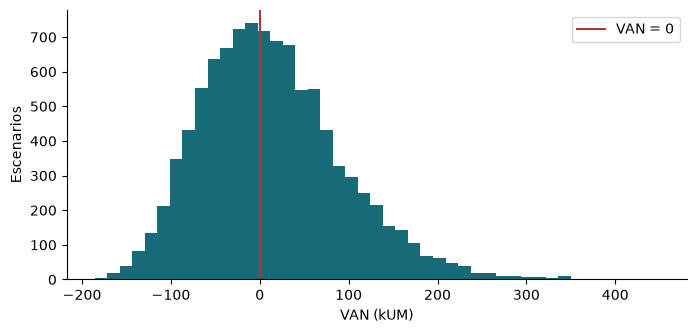

In [4]:
tabla = []
for n in [1000, 5000, 20000]:
    rr = resumen_solar(solar(n=n))
    tabla.append({"N": n, **rr})
display(pd.DataFrame(tabla))
fig, ax = plt.subplots()
ax.hist(escenarios.VAN, bins=45, color="#176b78")
ax.axvline(0, color="#a53939", label="VAN = 0")
ax.set(xlabel="VAN (kUM)", ylabel="Escenarios")
ax.legend()
plt.show()
plt.close(fig)

<a id="sensibilidad"></a>
## 3. Sensibilidad estructural y números aleatorios comunes

Al cambiar tasa, precio o dependencia se usan los mismos normales de base para comparar escenarios
con menor ruido. Se debe variar también el horizonte o modelo de shocks en una evaluación real.
Mayor precio debe aumentar el VAN en cada escenario; es una propiedad estructural que podemos
comprobar, más fuerte que verificar que la celda termina. El control de correlación explora una
hipótesis, no estima un parámetro de datos observados.

In [5]:
@widgets.interact(
    tasa=widgets.FloatSlider(value=0.10, min=0, max=0.25, step=0.01),
    precio=widgets.FloatSlider(value=1, min=0.7, max=1.3, step=0.05),
    rho=widgets.FloatSlider(value=-0.25, min=-0.8, max=0.8, step=0.05),
)
def explorar_solar(tasa=0.10, precio=1.0, rho=-0.25):
    s = solar(n=5000, tasa=tasa, escala_precio=precio, rho=rho)
    display(pd.Series(resumen_solar(s)))
    fig, ax = plt.subplots()
    ax.hist(s.VAN, bins=35, color="#176b78")
    ax.axvline(0, color="red")
    ax.set(xlabel="VAN (kUM)", ylabel="Frecuencia")
    plt.show()
    plt.close(fig)


bajo = solar(escala_precio=0.9)
alto = solar(escala_precio=1.1)
assert np.all(alto.VAN > bajo.VAN)
assert np.array_equal(solar(n=1000).VAN.to_numpy(), solar(n=1000).VAN.to_numpy())

interactive(children=(FloatSlider(value=0.1, description='tasa', max=0.25, step=0.01), FloatSlider(value=1.0, …

<a id="validacion"></a>
## 4. Contraste analítico de la media simulada

Para lognormales con normales latentes correlacionados,
$E[QP]=E[Q]E[P]\exp(\rho\sigma_Q\sigma_P)$. Por tanto, con los shocks persistentes y costos
fijos del caso, la media del VAN tiene una expresión cerrada. Contrastamos contra Monte Carlo
usando un margen de cinco errores estándar, no igualdad exacta ni una cifra copiada del programa.
Esta comprobación detecta errores de unidades, parametrización y descuento.

In [6]:
media_ingreso = 1000 * 100 * np.exp(-0.25 * 0.12 * 0.20) / 1000
van_analitico = -250 + (media_ingreso - 30) * sum(1 / 1.1**t for t in range(1, 6))
assert abs(r["VAN_medio"] - van_analitico) < 5 * r["SE_media"]
display(
    pd.Series(
        {"media_analitica": van_analitico, "media_MC": r["VAN_medio"], "SE_MC": r["SE_media"]}
    )
)

media_analitica    13.087412
media_MC           13.470587
SE_MC               0.796077
dtype: float64

### Extensión: cambiar dependencia temporal

Se mantienen marginales de precio/producción y su correlación dentro del año, pero ahora los shocks
son independientes entre años. Esto cambia riesgo económico, no solo precisión Monte Carlo.
Los percentiles y probabilidad de pérdida se comparan sin suponer que el caso más favorable sea el verdadero.

In [7]:
rng_anual = np.random.default_rng(SEMILLA)
z_anual = rng_anual.standard_normal((10000, 5, 2))
rho_anual = -0.25
latente_precio = rho_anual * z_anual[:, :, 0] + np.sqrt(1 - rho_anual**2) * z_anual[:, :, 1]
q_anual = 1000 * np.exp(0.12 * z_anual[:, :, 0] - 0.12**2 / 2)
p_anual = 100 * np.exp(0.20 * latente_precio - 0.20**2 / 2)
van_anual = -250 + ((q_anual * p_anual / 1000 - 30) / 1.1 ** np.arange(1, 6)).sum(axis=1)
comparacion_dependencia = pd.DataFrame(
    {
        "Persistentes": resumen_solar(solar(n=10000)),
        "Anuales independientes": resumen_solar(pd.DataFrame({"VAN": van_anual})),
    }
)
display(comparacion_dependencia)
assert abs(van_anual.mean() - van_analitico) < 5 * van_anual.std(ddof=1) / np.sqrt(len(van_anual))

,Persistentes,Anuales independientes
VAN_medio,13.470587,13.332677
P_perdida,0.471700,0.373200
P05,-100.608507,-41.620927
P95,158.381497,73.811735
SE_media,0.796077,0.353450
SE_probabilidad,0.004992,0.004837


<a id="propuesta"></a>
## 5. Entrega formativa S09 con solución orientadora

Prepare una ficha de dos páginas: alternativa base (no invertir, VAN incremental 0), proyecto,
supuestos, VAN esperado, probabilidad de pérdida, incertidumbre y factibilidad. Compare contra un
límite de riesgo **supuesto por el decisor**; por ejemplo, P(VAN<0) ≤ 25%. Si no cumple, no cambie
el umbral para aprobarlo: investigue contrato de precio, tamaño del proyecto o aplazamiento.

**Solución orientadora:** reportar que rentabilidad media positiva puede coexistir con riesgo de
pérdida significativo; distinguir incertidumbre del negocio y precisión MC; validar costos y
dependencia con fuentes; proponer revisión técnica y un hito de decisión. El límite 25% es
ilustrativo, no institucional. Rúbrica formativa: formulación 25%, calidad y supuestos 25%,
validación/sensibilidad 25%, recomendación y factibilidad 25%. No reemplaza una evaluación oficial.

In [8]:
limite = 0.25
ficha = {
    "alternativa": "SolarSur",
    "VAN_medio_kUM": r["VAN_medio"],
    "P_perdida": r["P_perdida"],
    "limite_riesgo_supuesto": limite,
    "cumple_riesgo": r["P_perdida"] <= limite,
    "siguiente_evidencia": "Validar distribución de precio, producción y costos; revisar contrato",
}
display(pd.Series(ficha))

alternativa                                                        SolarSur
VAN_medio_kUM                                                     13.470587
P_perdida                                                            0.4717
limite_riesgo_supuesto                                                 0.25
cumple_riesgo                                                         False
siguiente_evidencia       Validar distribución de precio, producción y c...
dtype: object

<a id="autoevaluacion"></a>
## Autoevaluación
Seleccione y compruebe su respuesta.

In [9]:
auto_06 = pregunta(
    "¿Qué reduce aumentar el número de simulaciones?",
    [
        "La incertidumbre económica del proyecto",
        "El error numérico de Monte Carlo",
        "La posibilidad de que el modelo esté equivocado",
    ],
    1,
    "El modelo mantiene sus supuestos y dispersión; N mejora la precisión de estimación bajo esos supuestos.",
)

## Práctica de transferencia 06

Duplica N manteniendo el modelo y después cambia shocks persistentes por anuales independientes. Predice qué cambia en SE y en la dispersión de VAN antes de ejecutar. Redacta una recomendación con límite de riesgo supuesto.

**Entrega:** hipótesis previa, cálculo con unidades, interpretación y límite. Completa tu respuesta antes de consultar la [pauta docente](../material_propio/PAUTA_DOCENTE.md#nb06).

**Discusión:** ¿Qué parámetro económico necesitas estimar con datos externos antes de decidir?

### Tu resolución

Edita esta celda: escribe tu hipótesis, procedimiento, resultado, interpretación y una comprobación. Adjunta tu código o gráfico si la actividad lo requiere.

**Auto-revisión:** ¿usé la población correcta?, ¿declaré unidades y supuestos?, ¿mi evidencia permite esa conclusión?